# Leave-one-out $\lambda_m$ and $\rho_m$

Perfect-model skill from each member against the mean of the others. For every grid cell
and every member $n$, with $s_{-n}$ the ensemble mean over the other $N-1$ members:

$$I_n = I\big(f_n;s_{-n}\big),\quad
\lambda_m = \frac1N\sum_n \sqrt{1-e^{-2I_n}},\qquad
\rho_m = \frac1N\sum_n \mathrm{corr}\big(f_n,s_{-n}\big)$$

$\lambda$ is formed per member and *then* averaged; averaging $I_n$ first and transforming
once gives a different, larger number. MI comes from `infomeasure`'s KSG estimator via
`scripts/infomeasure_rpc.py` (nats, `noise_level=0`, max norm, rank/copula transform,
$k=5$).

Both are computed on the data as it comes and on month-of-year anomalies, since the
preprocessing removes a linear trend but no seasonal cycle.

**Handles**

| name | shape | meaning |
|---|---|---|
| `I_N[t]` | `(49, 64, 128)` | $I_n$ in nats, per member |
| `LAM_N[t]` | `(49, 64, 128)` | $\lambda_n$, per member |
| `LAM_M[t]` | `(64, 128)` | $\lambda_m$ |
| `R_N[t]` | `(49, 64, 128)` | $r_n$, per member |
| `RHO_M[t]` | `(64, 128)` | $\rho_m$ |
| `rho_m_var` | `(64, 128)` | published variance-based $\rho_m$, for reference |

`t` is one of `TREATMENTS`; `panel(ax, field, cmap, norm, title)` draws a map.

In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)

DATA = "../data" if os.path.isdir("../data/ensembles") else \
    "/Users/jasperchen/Academics/Research/SNP/information-snp/data"
f, s, obs = R.load_data(data_dir=DATA)
lats, lons = f["lat"].to_numpy(), f["lon"].to_numpy()

# Repair the two defective edge longitude columns. In the raw ensemble file members
# 10-19 have no data at all at lon index 0 (0.00E) and members 20-39 none at index 127
# (357.19E) -- whole model groups missing one edge column, from regridding onto the
# common grid without periodic longitude handling. Zero-filled they read as a stripe
# down the middle of every rolled map. Fill each from its nearest longitude neighbour;
# timesteps missing for other reasons (calendar 1971 for members 10-19) stay NaN.
_psl = f.psl.to_numpy()
for _bad, _good in ((0, 1), (127, 126)):
    _col = _psl[:, :, :, _bad]
    _psl[:, :, :, _bad] = np.where(np.isnan(_col), _psl[:, :, :, _good], _col)
f["psl"] = (f.psl.dims, _psl)
s = f.mean("n")

rho_m_var = R.var_RPC(f, s, obs)[1].to_numpy()

PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180        # grid is 0..357E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=12)
    return h

## Leave-one-out means

`loo_mean(n)` returns $s_{-n}$ as a `(T, lat, lon)` field, built from the total nan-aware
sum and count rather than 49 separate `nanmean` calls -- exact, and avoids a second copy
of the ensemble.

In [2]:
F = f.psl.to_numpy()                       # (N, T, lat, lon), NaNs intact
N, T = F.shape[:2]
_valid = ~np.isnan(F)
_sum = np.nansum(F, axis=0)
_count = _valid.sum(axis=0)
month = np.arange(T) % 12


def loo_mean(n):
    """Ensemble mean excluding member n: nan-aware, then zero-filled."""
    num = _sum - np.where(_valid[n], F[n], 0.0)
    den = _count - _valid[n]
    return np.nan_to_num(np.where(den > 0, num / np.maximum(den, 1), np.nan), nan=0.0)


def deseason(a):
    """Subtract the month-of-year climatology along the time axis."""
    out = a.copy()
    for m in range(12):
        sel = month == m
        out[sel] = a[sel] - a[sel].mean(axis=0, keepdims=True)
    return out


def pair(n, treatment):
    """(f_n, s_-n) ready for an estimator, both (T, lat, lon)."""
    f_n, s_n = np.nan_to_num(F[n], nan=0.0), loo_mean(n)
    return (deseason(f_n), deseason(s_n)) if treatment == "deseasonalised" else (f_n, s_n)


with warnings.catch_warnings():                            # loo_mean is exact
    warnings.simplefilter("ignore", RuntimeWarning)
    for _n in (0, 12, 48):
        _d = np.nan_to_num(np.nanmean(np.delete(F[:, :, 32, 21], _n, axis=0), axis=0), nan=0.0)
        assert np.allclose(loo_mean(_n)[:, 32, 21], _d)

## The permutation null, and why one constant is enough

Every $I$ below is a KSG estimate at $T=120$, and KSG has no analytic bias correction — its
digamma terms are the estimator itself, not a correction layered on top. `infomeasure`
offers the analytic route only for its discrete families (`miller_madow` and relatives add
$\big(\sum_i K_i - i - K_{\mathrm{joint}} + 1\big)/2N$ to the plug-in estimate). For KSG the
only route is resampling, which the library also provides:
`estimator.statistical_test(n_tests, method="permutation_test")` permutes the first variable
along axis 0, leaves the others aligned, and reports `null_mean` over `n_tests` draws.

It is `null_mean` that is wanted, not the `effective_val` shortcut, which subtracts a
*single* permutation: the null's standard deviation is about 0.04 nats here, so one draw is
useless as a bias estimate.

**Why a constant rather than a field.** After the copula transform both variables are
exactly uniform on $[0,1]$, so nothing about the field survives into the null — only $T$,
$k$ and the size of the conditioning set. Measured over a spatial sample the null sits at
$\approx0.024$ nats with a between-case spread of about 0.007, most of which is the
Monte-Carlo error of the null itself. So the correction is one constant, which is what makes
correcting the whole grid affordable: a null *field* would cost `n_tests` times the run that
produced the estimate.

This cell covers the unconditional null, which is the one every $\lambda$ on this page
needs — $I(f_n;s_{-n})$, $I(f_n;g)$ and $I(s;g)$ are all 1-D against 1-D. The chain rule's
*conditional* nulls need the feature summary and are measured further down, next to the
chain itself.

Everything downstream goes through `excess_mi`, so every $\lambda$ in this notebook is built
from $I - I_{\mathrm{null}}$. `lam` clamps at zero, so a cell whose $I$ fails to clear the
null comes out at exactly $\lambda=0$ instead of at the $\approx0.12$ floor the raw
estimator imposes.

Adds `NULL_NATS[treatment]` and `excess_mi(I, treatment)`.

In [3]:
import infomeasure as im     # for the estimator objects, which carry statistical_test

TREATMENTS = ["as-is", "deseasonalised"]
K = 5                        # KSG neighbours, this project's default
NULL_POINTS = [(la, lo) for la in range(3, 64, 5) for lo in range(0, 128, 11)]
NULL_MEMBERS = [0, 16, 32, 48]
NULL_TESTS = 60


def to_ranks(a):
    """Rank/copula transform, column-wise for 2-D input."""
    a = np.asarray(a, float)
    return R.copula(a) if a.ndim == 1 else np.column_stack(
        [R.copula(a[:, j]) for j in range(a.shape[1])])


def mi_null_nats(x, y, given=None, n_tests=NULL_TESTS):
    """Mean of the permutation null in nats, from infomeasure's statistical_test."""
    if given is None:
        estimator = im.estimator(to_ranks(x), to_ranks(y), measure="mi", approach="ksg",
                                 k=K, noise_level=0, minkowski_p=np.inf)
    else:
        estimator = im.estimator(to_ranks(x), to_ranks(y), cond=to_ranks(given),
                                 measure="cmi", approach="ksg", k=K,
                                 noise_level=0)
    return float(estimator.statistical_test(
        n_tests=n_tests, method="permutation_test").null_mean)


def unconditional_nulls(treatment):
    """One null per (sampled point, sampled member) for I(f_n ; s_-n)."""
    out = []
    for lat_idx, lon_idx in NULL_POINTS:
        for held in NULL_MEMBERS:
            f_n, s_n = pair(held, treatment)
            out.append(mi_null_nats(s_n[:, lat_idx, lon_idx], f_n[:, lat_idx, lon_idx]))
    return np.array(out)


NULL_NATS, _null_sd = {}, {}
for _treatment in TREATMENTS:
    _samples = unconditional_nulls(_treatment)
    NULL_NATS[_treatment] = float(_samples.mean())
    _null_sd[_treatment] = float(_samples.std(ddof=1))


def excess_mi(I, treatment="as-is"):
    """I minus the unconditional permutation null, in nats."""
    return np.asarray(I, float) - NULL_NATS[treatment]


# The null is a property of the estimator, not of the pair: scoring against the
# observations instead of against s_-n must give the same floor.
_obs_null = np.mean([mi_null_nats(np.nan_to_num(obs.psl.to_numpy()[:, la, lo], nan=0.0),
                                  np.nan_to_num(F[0, :, la, lo], nan=0.0))
                     for la, lo in NULL_POINTS[::4]])
assert abs(_obs_null - NULL_NATS["as-is"]) < 0.0035

print("%d points x %d members, %d permutations each"
      % (len(NULL_POINTS), len(NULL_MEMBERS), NULL_TESTS))
print("%-16s %9s %12s %12s" % ("treatment", "null", "across-case", "se of mean"))
for _treatment in TREATMENTS:
    print("%-16s %9.4f %12.4f %12.4f"
          % (_treatment, NULL_NATS[_treatment], _null_sd[_treatment],
             _null_sd[_treatment] / np.sqrt(len(NULL_POINTS) * len(NULL_MEMBERS))))
print("%-16s %9.4f   (against the observations instead of s_-n)"
      % ("as-is", _obs_null))

156 points x 4 members, 60 permutations each
treatment             null  across-case   se of mean
as-is               0.0242       0.0070       0.0003
deseasonalised      0.0216       0.0060       0.0002
as-is               0.0213   (against the observations instead of s_-n)


## $\lambda_m$

One KSG call per member per grid cell, $49\times64\times128$ of them. A cold run of both
treatments takes about eight minutes, so it is cached.

In [4]:
CACHE = "../data/granger_lin_cache_nats.npz"


def lam(I):
    """sqrt(1 - exp(-2I)) for I in nats, argument of the sqrt clamped at 0."""
    return np.sqrt(np.maximum(0.0, 1.0 - np.exp(-2.0 * I)))


def loo_mi(treatment):
    """I(f_n ; s_-n) for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        f_n, s_n = pair(n, treatment)
        for la in range(F.shape[2]):
            for lo in range(F.shape[3]):
                out[n, la, lo] = R.mi_nats(f_n[:, la, lo], s_n[:, la, lo], "ksg", param=K)
    return out


if os.path.exists(CACHE):
    _z = np.load(CACHE)
    I_N = {t: _z[t] for t in TREATMENTS}
else:
    I_N = {t: loo_mi(t) for t in TREATMENTS}
    np.savez_compressed(CACHE, **I_N)

LAM_N = {t: lam(excess_mi(I_N[t], t)) for t in TREATMENTS}              # (N, lat, lon)
LAM_M = {t: LAM_N[t].mean(axis=0) for t in TREATMENTS}    # (lat, lon)

## $\rho_m$

Same construction, Pearson correlation instead of MI. Vectorised over the grid, so this is
seconds and needs no cache.

In [5]:
def loo_pearson(treatment):
    """corr(f_n, s_-n) for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        f_n, s_n = pair(n, treatment)
        a = f_n - f_n.mean(axis=0, keepdims=True)
        b = s_n - s_n.mean(axis=0, keepdims=True)
        den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
        with np.errstate(invalid="ignore", divide="ignore"):
            out[n] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    return out


R_N = {t: loo_pearson(t) for t in TREATMENTS}             # (N, lat, lon)
RHO_M = {t: np.nanmean(R_N[t], axis=0) for t in TREATMENTS}   # (lat, lon)

_ok = np.isfinite(rho_m_var)
print("%-15s %8s %8s %8s" % ("treatment", "lam_m", "rho_m", "corr"))
for t in TREATMENTS:
    m = np.isfinite(LAM_M[t]) & np.isfinite(RHO_M[t])
    print("%-15s %8.4f %+8.4f %+8.3f"
          % (t, LAM_M[t].mean(), np.nanmean(RHO_M[t]),
             np.corrcoef(LAM_M[t][m], RHO_M[t][m])[0, 1]))
print("\nrho_m as-is vs published variance-based rho_m: corr %+.3f, means %.4f / %.4f"
      % (np.corrcoef(RHO_M["as-is"][_ok], rho_m_var[_ok])[0, 1],
         np.nanmean(RHO_M["as-is"]), rho_m_var[_ok].mean()))

treatment          lam_m    rho_m     corr
as-is             0.6089  +0.5753   +0.991
deseasonalised    0.1454  +0.0449   +0.499

rho_m as-is vs published variance-based rho_m: corr +0.997, means 0.5753 / 0.6083


## Maps

One figure per treatment: $\lambda_m$ left, $\rho_m$ right, sharing a colour scale that
spans both panels.

The vertical line down the centre of every map is longitude 0 (the prime meridian, not the date line -- that sits at the map edges). Original longitude columns 0 (0.00E) and 127 (357.19E) are 20.7% and 42.9% NaN in the raw ensemble file: members 10-19 are missing column 0 entirely and members 20-39 column 127 entirely, from regridding onto the common grid without periodic longitude handling. Rolling to -180..180 puts those two columns adjacent at plotted columns 63 and 64, i.e. dead centre. The observations are 0% NaN throughout.

['as-is', 'deseasonalised']
0
1


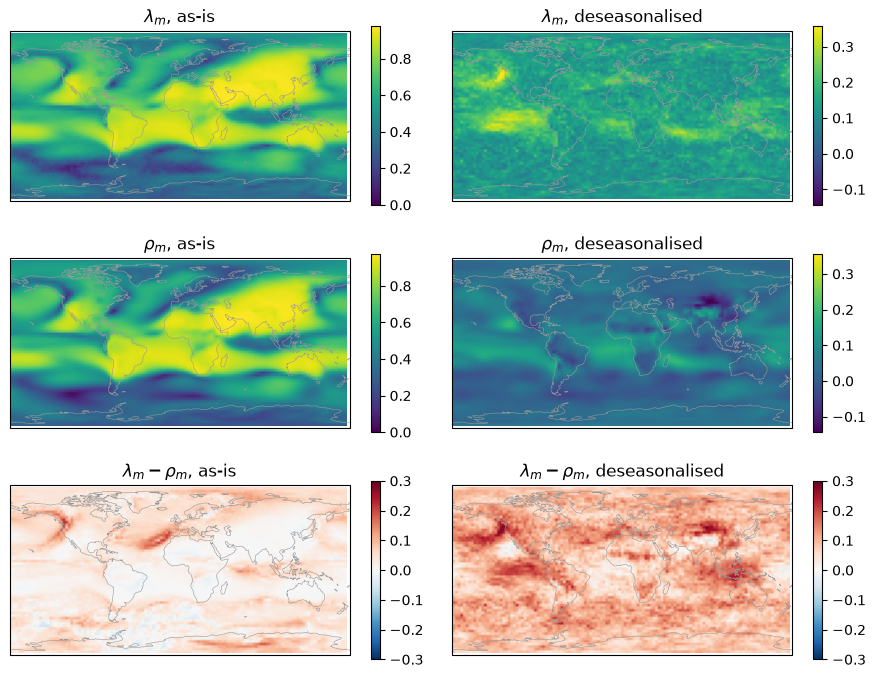

In [6]:
print(TREATMENTS)

fig, axs = plt.subplots(3, 2, figsize=(9, 7),
                        subplot_kw={"projection": PROJ})
for (i, t) in enumerate(TREATMENTS):
    print(i)
    a, b = LAM_M[t], RHO_M[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    nrm_compare = Normalize(-0.3, 0.3)
    h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_m$, %s" % t)
    h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_m$, %s" % t)
    h2 = panel(axs[2, i], a-b, "RdBu_r", nrm_compare, "$\\lambda_m - \\rho_m$, %s" % t)
    fig.colorbar(h0, ax=axs[0, i], shrink=0.85, label="")
    fig.colorbar(h1, ax=axs[1, i], shrink=0.85, label="")
    fig.colorbar(h2, ax=axs[2, i], shrink=0.85, label="")
plt.tight_layout()
plt.show()

## $\lambda_m$ against $\rho_m$, and the spread across members

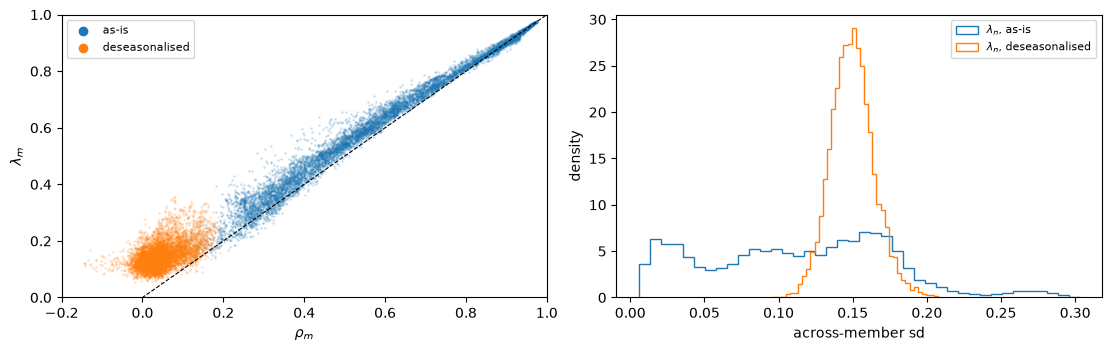

treatment         lam_n sd     r_n sd        I_n<0
as-is                0.113      0.104         2.0%
deseasonalised       0.150      0.110        27.9%


In [7]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[0].scatter(RHO_M[t].ravel(), LAM_M[t].ravel(), s=1, alpha=0.15, color=c, label=t)
axs[0].plot([-0.2, 1], [-0.2, 1], "k--", lw=0.8)
axs[0].set_xlabel("$\\rho_m$")
axs[0].set_ylabel("$\\lambda_m$")
axs[0].set_xlim(-0.2, 1)
axs[0].set_ylim(0, 1)
leg = axs[0].legend(fontsize=8, markerscale=6)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[1].hist(LAM_N[t].std(axis=0).ravel(), bins=40, histtype="step",
                density=True, color=c, label="$\\lambda_n$, %s" % t)
axs[1].set_xlabel("across-member sd")
axs[1].set_ylabel("density")
axs[1].legend(fontsize=8)
plt.show()

print("%-15s %10s %10s %12s" % ("treatment", "lam_n sd", "r_n sd", "I_n<0"))
for t in TREATMENTS:
    print("%-15s %10.3f %10.3f %11.1f%%"
          % (t, LAM_N[t].std(axis=0).mean(), np.nanstd(R_N[t], axis=0).mean(),
             100 * np.mean(I_N[t] < 0)))

## $\lambda_o$ and $\rho_o$

Same construction with the observations $g$ in place of $s_{-n}$, so there is nothing to
leave out -- each member is scored against the same external target:

$$\lambda_o = \frac1N\sum_n \sqrt{1-e^{-2\,I(f_n;\,g)}},\qquad
\rho_o = \frac1N\sum_n \mathrm{corr}\big(f_n,g\big)$$

`mi_grid` and `pearson_grid` take whichever pairing function they are given, so the model
and observation sides cannot drift apart in their NaN or deseasonalising handling.

Adds `I_O[t]`, `LAM_O_N[t]`, `R_O_N[t]` at `(49, 64, 128)` and `LAM_O[t]`, `RHO_O[t]` at
`(64, 128)`, plus `rho_o_var` = published $\mathrm{corr}(s,g)$ for reference.

In [8]:
OBS_CACHE = "../data/granger_lin_obs_cache_nats.npz"
G = np.nan_to_num(obs.psl.to_numpy(), nan=0.0)          # (T, lat, lon)
G_ds = deseason(G)
rho_o_var = R.var_RPC(f, s, obs)[0].to_numpy()


def pair_obs(n, treatment):
    """(f_n, g) ready for an estimator, both (T, lat, lon)."""
    f_n = np.nan_to_num(F[n], nan=0.0)
    if treatment == "deseasonalised":
        return deseason(f_n), G_ds
    return f_n, G


def mi_grid(pairfn, treatment):
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        x, y = pairfn(n, treatment)
        for la in range(F.shape[2]):
            for lo in range(F.shape[3]):
                out[n, la, lo] = R.mi_nats(x[:, la, lo], y[:, la, lo], "ksg", param=K)
    return out


def pearson_grid(pairfn, treatment):
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        x, y = pairfn(n, treatment)
        a = x - x.mean(axis=0, keepdims=True)
        b = y - y.mean(axis=0, keepdims=True)
        den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
        with np.errstate(invalid="ignore", divide="ignore"):
            out[n] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    return out


if os.path.exists(OBS_CACHE):
    _z = np.load(OBS_CACHE)
    I_O = {t: _z[t] for t in TREATMENTS}
else:
    I_O = {t: mi_grid(pair_obs, t) for t in TREATMENTS}
    np.savez_compressed(OBS_CACHE, **I_O)

LAM_O_N = {t: lam(excess_mi(I_O[t], t)) for t in TREATMENTS}                 # (N, lat, lon)
LAM_O = {t: LAM_O_N[t].mean(axis=0) for t in TREATMENTS}       # (lat, lon)
R_O_N = {t: pearson_grid(pair_obs, t) for t in TREATMENTS}     # (N, lat, lon)
RHO_O = {t: np.nanmean(R_O_N[t], axis=0) for t in TREATMENTS}  # (lat, lon)

_ok_o = np.isfinite(rho_o_var)
print("%-15s %8s %8s %8s" % ("treatment", "lam_o", "rho_o", "corr"))
for t in TREATMENTS:
    m = np.isfinite(LAM_O[t]) & np.isfinite(RHO_O[t])
    print("%-15s %8.4f %+8.4f %+8.3f"
          % (t, LAM_O[t].mean(), np.nanmean(RHO_O[t]),
             np.corrcoef(LAM_O[t][m], RHO_O[t][m])[0, 1]))
print("\npublished corr(s, g): mean %.4f, corr with rho_o as-is %+.3f"
      % (rho_o_var[_ok_o].mean(),
         np.corrcoef(RHO_O["as-is"][_ok_o], rho_o_var[_ok_o])[0, 1]))

treatment          lam_o    rho_o     corr
as-is             0.4646  +0.4241   +0.988
deseasonalised    0.1351  +0.0034   +0.003

published corr(s, g): mean 0.6252, corr with rho_o as-is +0.940


## Maps

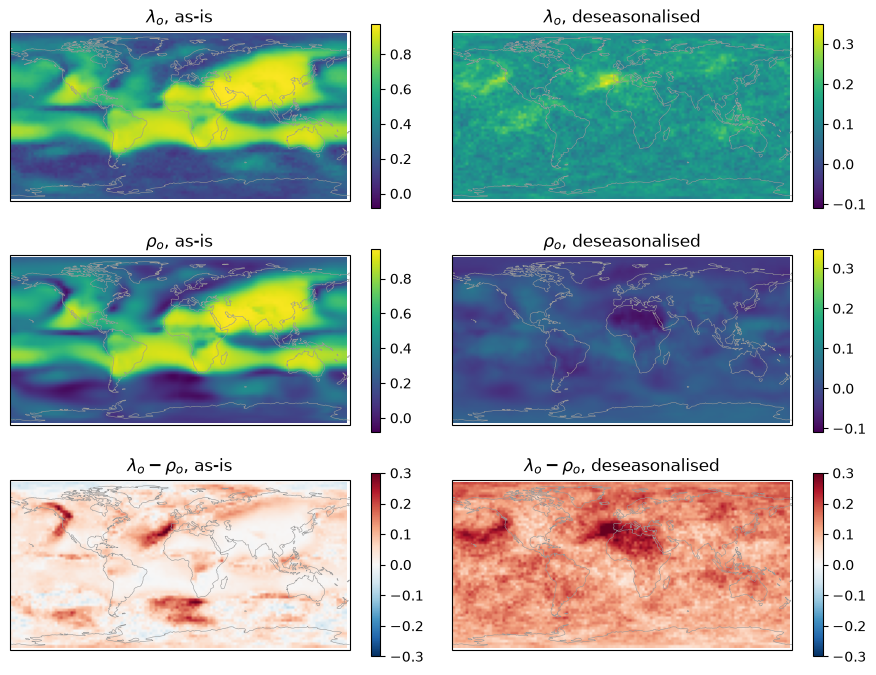

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(9, 7),
                        subplot_kw={"projection": PROJ})
for (i, t) in enumerate(TREATMENTS):
    a, b = LAM_O[t], RHO_O[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    nrm_compare = Normalize(-0.3, 0.3)
    h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_o$, %s" % t)
    h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_o$, %s" % t)
    h2 = panel(axs[2, i], a-b, "RdBu_r", nrm_compare, "$\\lambda_o - \\rho_o$, %s" % t)
    fig.colorbar(h0, ax=axs[0, i], shrink=0.85, label="")
    fig.colorbar(h1, ax=axs[1, i], shrink=0.85, label="")
    fig.colorbar(h2, ax=axs[2, i], shrink=0.85, label="")
plt.tight_layout()
plt.show()

## $\lambda_o$ against $\rho_o$, and the spread across members

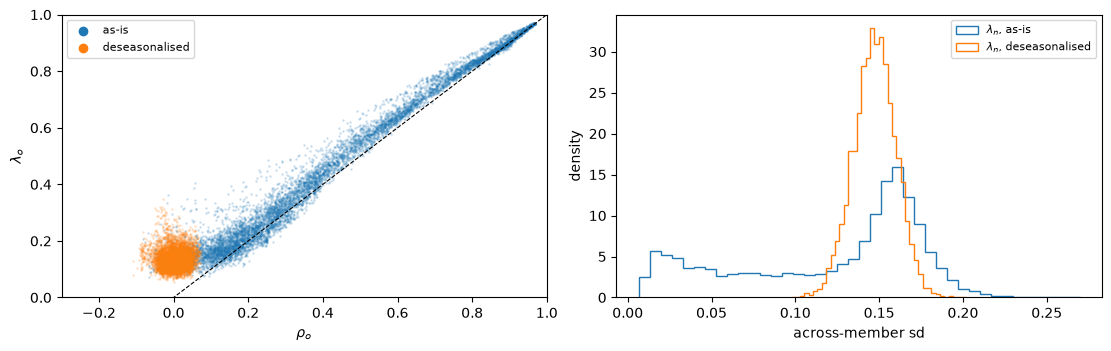

treatment         lam_n sd     r_n sd        I_n<0
as-is                0.121      0.096         7.7%
deseasonalised       0.147      0.110        29.6%


In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[0].scatter(RHO_O[t].ravel(), LAM_O[t].ravel(), s=1, alpha=0.15, color=c, label=t)
axs[0].plot([-0.3, 1], [-0.3, 1], "k--", lw=0.8)
axs[0].set_xlabel("$\\rho_o$")
axs[0].set_ylabel("$\\lambda_o$")
axs[0].set_xlim(-0.3, 1)
axs[0].set_ylim(0, 1)
leg = axs[0].legend(fontsize=8, markerscale=6)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[1].hist(LAM_O_N[t].std(axis=0).ravel(), bins=40, histtype="step",
                density=True, color=c, label="$\\lambda_n$, %s" % t)
axs[1].set_xlabel("across-member sd")
axs[1].set_ylabel("density")
axs[1].legend(fontsize=8)
plt.show()

print("%-15s %10s %10s %12s" % ("treatment", "lam_n sd", "r_n sd", "I_n<0"))
for t in TREATMENTS:
    print("%-15s %10.3f %10.3f %11.1f%%"
          % (t, LAM_O_N[t].std(axis=0).mean(), np.nanstd(R_O_N[t], axis=0).mean(),
             100 * np.mean(I_O[t] < 0)))

## $\lambda_o$ and $\rho_o$ the other way round: average the ensemble first

Above, each member was scored against $g$ and the skills were averaged. Here the ensemble
is collapsed to its mean $s$ first, and only that one series is compared with $g$:

$$\rho_o^{\,s} = \mathrm{corr}(s, g), \qquad
\lambda_o^{\,s} = \sqrt{1 - e^{-2\,I(s;\,g)}}$$

One estimate per grid cell instead of 49, so this is seconds and needs no cache. $s$ is the
published skipna ensemble mean.

Adds `LAM_O_S[t]` and `RHO_O_S[t]` at `(64, 128)`. Note $\rho_o^{\,s}$ is left unclamped;
the published `rho_o_var` is the same field with negatives set to zero.

In [11]:
S = np.nan_to_num(s.psl.to_numpy(), nan=0.0)            # published skipna ensemble mean
S_ds = deseason(S)


def sig_pair(treatment):
    return (S_ds, G_ds) if treatment == "deseasonalised" else (S, G)


RHO_O_S, LAM_O_S = {}, {}
for t in TREATMENTS:
    x, y = sig_pair(t)
    a = x - x.mean(axis=0, keepdims=True)
    b = y - y.mean(axis=0, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        RHO_O_S[t] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    LAM_O_S[t] = lam(excess_mi(
        np.array([[R.mi_nats(x[:, la, lo], y[:, la, lo], "ksg", param=K)
                   for lo in range(S.shape[2])]
                  for la in range(S.shape[1])]), t))

print("%-15s %9s %9s %11s %11s" % ("treatment", "lam_o^s", "rho_o^s",
                                   "lam_o (mem)", "rho_o (mem)"))
for t in TREATMENTS:
    print("%-15s %9.4f %+9.4f %11.4f %+11.4f"
          % (t, LAM_O_S[t].mean(), np.nanmean(RHO_O_S[t]),
             LAM_O[t].mean(), np.nanmean(RHO_O[t])))
print("\nrho_o^s as-is is the published rho_o up to its clamp at zero: %s (%.1f%% of "
      "cells are negative)"
      % (np.allclose(np.maximum(RHO_O_S["as-is"], 0.0), rho_o_var, equal_nan=True),
         100 * np.mean(RHO_O_S["as-is"] < 0)))

treatment         lam_o^s   rho_o^s lam_o (mem) rho_o (mem)
as-is              0.6770   +0.6237      0.4646     +0.4241
deseasonalised     0.1404   +0.0310      0.1351     +0.0034

rho_o^s as-is is the published rho_o up to its clamp at zero: True (1.7% of cells are negative)


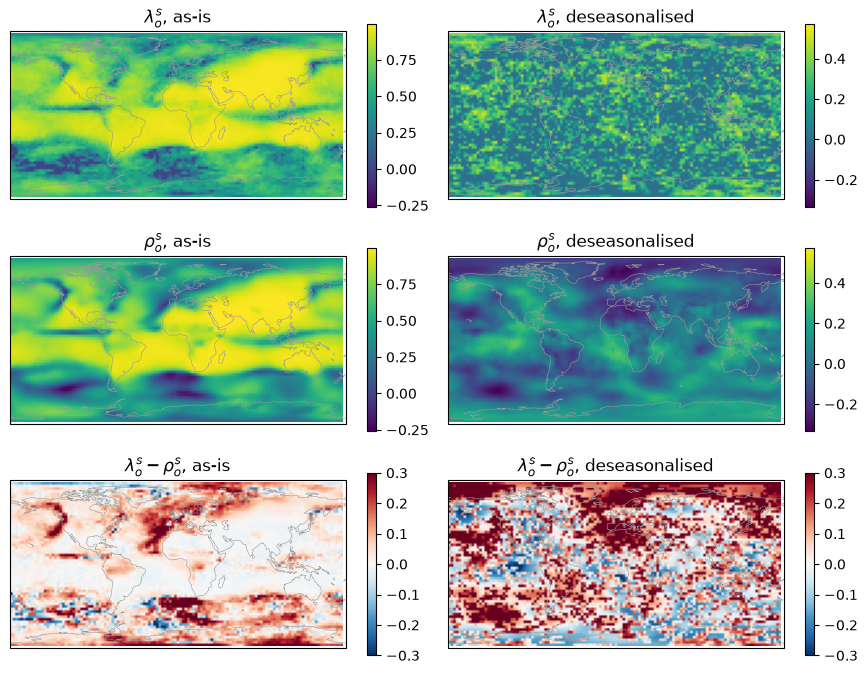

In [12]:
fig, axs = plt.subplots(3, 2, figsize=(9, 7),
                        subplot_kw={"projection": PROJ})
for (i, t) in enumerate(TREATMENTS):
    a, b = LAM_O_S[t], RHO_O_S[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    nrm_compare = Normalize(-0.3, 0.3)
    h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_o^s$, %s" % t)
    h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_o^s$, %s" % t)
    h2 = panel(axs[2, i], a-b, "RdBu_r", nrm_compare, "$\\lambda_o^s - \\rho_o^s$, %s" % t)
    fig.colorbar(h0, ax=axs[0, i], shrink=0.85, label="")
    fig.colorbar(h1, ax=axs[1, i], shrink=0.85, label="")
    fig.colorbar(h2, ax=axs[2, i], shrink=0.85, label="")
plt.tight_layout()
plt.show()

# Compare Ratio of Predictable Components

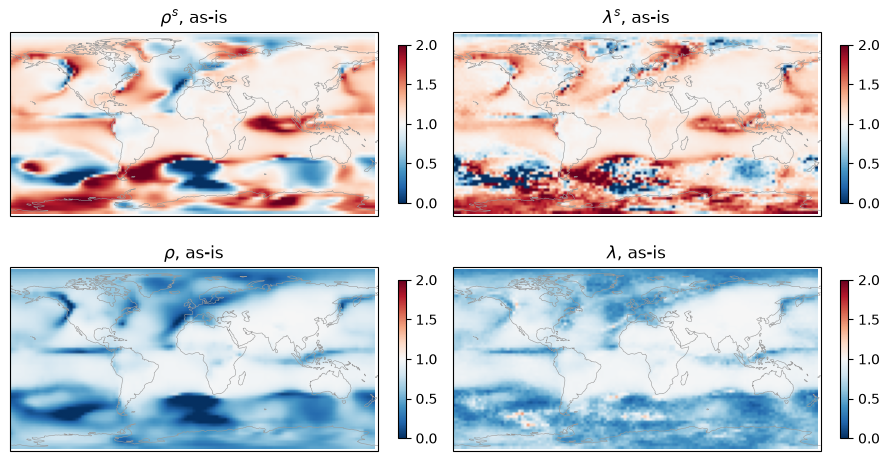

In [13]:
t='as-is'
fig, axs = plt.subplots(2, 2, figsize=(9, 5),
                        subplot_kw={"projection": PROJ})

lam_os, rho_os = LAM_O_S[t], RHO_O_S[t]
lam_o, rho_o = LAM_O[t], RHO_O[t]
lam_m, rho_m = LAM_M[t], RHO_M[t]

lam_s = lam_os / lam_m
rho_s = rho_os / rho_m 
lam = lam_o / lam_m
rho = rho_o / rho_m 

nrm = Normalize(0.0, 2.0)
nrm_compare = Normalize(-0.3, 0.3)
h0 = panel(axs[0,0], rho_s, "RdBu_r", nrm, "$\\rho^s$, %s" % t)
h1 = panel(axs[0,1], lam_s, "RdBu_r", nrm, "$\\lambda^s$, %s" % t)
h2 = panel(axs[1,0], rho, "RdBu_r", nrm, "$\\rho$, %s" % t)
h3 = panel(axs[1,1], lam, "RdBu_r", nrm, "$\\lambda$, %s" % t)
fig.colorbar(h0, ax=axs[0, 0], fraction=0.02)
fig.colorbar(h1, ax=axs[0, 1], fraction=0.02)
fig.colorbar(h2, ax=axs[1, 0], fraction=0.02)
fig.colorbar(h3, ax=axs[1, 1], fraction=0.02)
plt.tight_layout()

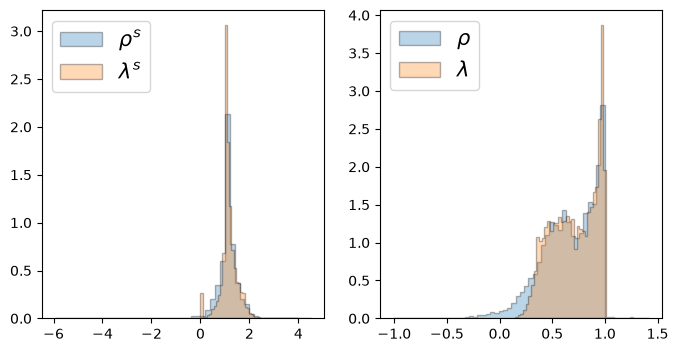

In [14]:
plot_kwargs = {'density': True, 'histtype': 'stepfilled', 'alpha':0.3, 'ec':'k', 'bins':50 }
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].hist(rho_s.flatten(), label='$\\rho^s$', **plot_kwargs)
axs[0].hist(lam_s.flatten(), label='$\\lambda^s$', **plot_kwargs)
axs[0].legend(fontsize=15)

axs[1].hist(rho.flatten(), label='$\\rho$', **plot_kwargs)
axs[1].hist(lam.flatten(), label='$\\lambda$', **plot_kwargs);
axs[1].legend(fontsize=15)


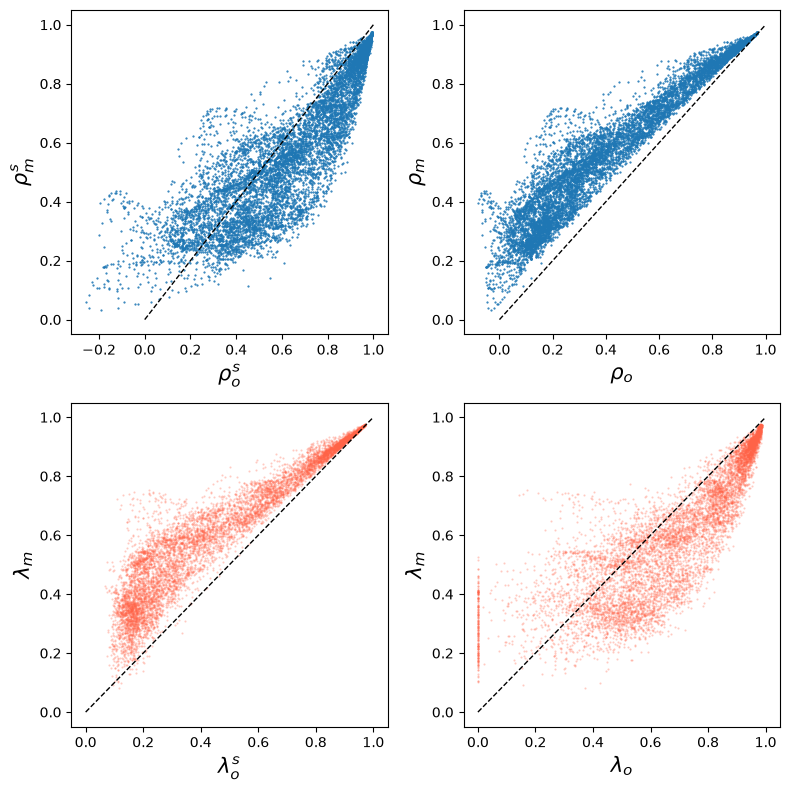

In [15]:
SZ = 0.3

LABEL_SIZE = 15

fig, axs = plt.subplots(2, 2, figsize=(8,8))

axs = axs.flatten() 

axs[0].scatter(rho_os, rho_m, SZ)
axs[1].scatter(rho_o, rho_m, SZ)
axs[2].scatter(lam_o, lam_m, SZ, c='tomato', alpha=0.3)
axs[3].scatter(lam_os, lam_m, SZ, c='tomato', alpha=0.3)

axs[0].set_xlabel('$\\rho_o^s$', fontsize=LABEL_SIZE)
axs[1].set_xlabel('$\\rho_o$', fontsize=LABEL_SIZE)
# axs[2].set_xlabel('$\\rho_m$', fontsize=LABEL_SIZE)
axs[0].set_ylabel('$\\rho_m^s$', fontsize=LABEL_SIZE)
axs[1].set_ylabel('$\\rho_m$', fontsize=LABEL_SIZE)
# axs[2].set_ylabel('$\\lambda_m$', fontsize=LABEL_SIZE)

axs[2].set_ylabel('$\\lambda_m$', fontsize=LABEL_SIZE)
axs[2].set_xlabel('$\\lambda_o^s$', fontsize=LABEL_SIZE)
axs[3].set_ylabel('$\\lambda_m$', fontsize=LABEL_SIZE)
axs[3].set_xlabel('$\\lambda_o$', fontsize=LABEL_SIZE)

xx = np.linspace(0, 1, 10)
for i in range(4):
    axs[i].plot(xx, xx, 'k--', lw=1)
plt.tight_layout()

Text(0.5, 0, '$\\rho^s$')

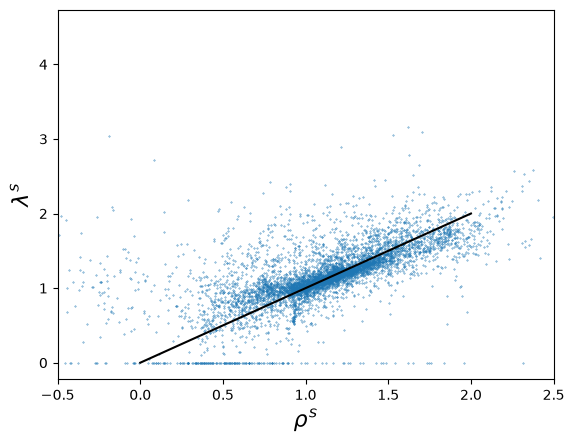

In [16]:
plt.scatter(rho_s, lam_s, 0.1)
x=np.linspace(0,2,20)
plt.plot(x, x, 'k-')
plt.xlim(-0.5, 2.5)
plt.ylabel('$\\lambda^s$', fontsize=16)
plt.xlabel('$\\rho^s$', fontsize=16)

Text(0.5, 0, '$\\rho$')

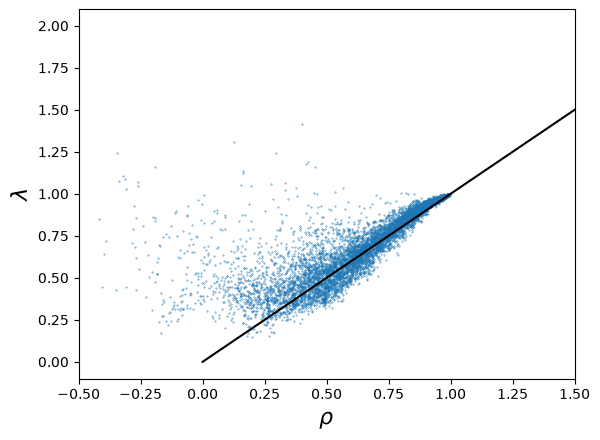

In [17]:
plt.scatter(rho, lam, 0.1)
x=np.linspace(0,2,20)
plt.plot(x, x, 'k-')
plt.xlim(-0.5, 1.5)
plt.ylabel('$\\lambda$', fontsize=16)
plt.xlabel('$\\rho$', fontsize=16)

In [18]:
print(np.max(lam_s) - np.min(lam_s))
print(np.max(rho_s) - np.min(rho_s))

4.504904566627579
9.940991987760674


## $I(f_n; F_{-n})$ by the conditional chain rule

$s_{-n}$ is a linear average, so it cannot carry non-linear structure in the leave-one-out
ensemble. Summarising $F_{-n}$ by four moments and estimating in one go pays a steep
dimension penalty at $T=120$; the chain rule gets the same quantity without ever leaving
low dimension:

$$I(f_n;\,\mu,\sigma,\mathrm{sk},\mathrm{ku}) = I(f_n;\mu)
+ I(\sigma;f_n\mid\mu) + I(\mathrm{sk};f_n\mid\mu,\sigma)
+ I(\mathrm{ku};f_n\mid\mu,\sigma,\mathrm{sk})$$

Each term comes from `im.cmi(extra, f_n, cond=already_included)`, so the conditioning set
never exceeds three variables. Each carries its own bias, so each gets its own null:
permute the extra feature in time with $f_n$ and the conditioning set left aligned.

The exact chain rule does not care about the order: all $4!=24$ orderings sum to the same
$I(f_n;\mu,\sigma,\mathrm{sk},\mathrm{ku})$. The estimator does care, because a KSG term
paid at three conditions is not the term paid at none. So the chain is run in the published
order and in reverse -- kurt, skew, std, mean -- and, since one table of 32 steps covers
every ordering, in all 24, against the order-free direct 4-D estimate.

mean-first                 value      null    excess
mean                     +0.3176   +0.0236   +0.2941
std | mean               +0.0382   +0.0197   +0.0185
skew | mean,std          +0.0288   +0.0203   +0.0084
kurt | mean,std,skew     +0.0179   +0.0196   -0.0016
chain-rule total         +0.4025             +0.3194

kurt-first                 value      null    excess
kurt                     +0.0214   +0.0239   -0.0025
skew | kurt              +0.0238   +0.0190   +0.0047
std | kurt,skew          +0.0998   +0.0201   +0.0797
mean | kurt,skew,std     +0.1426   +0.0200   +0.1225
chain-rule total         +0.2874             +0.2045

members   chain total    direct 4-D
      4        0.3001        0.1737
      6        0.3413        0.1919
      8        0.3323        0.1966
     12        0.3585        0.2111
     16        0.3751        0.2191
     24        0.3861        0.2251
     32        0.3924        0.2265
     40        0.3942        0.2315
     48        0.4025        0.2320


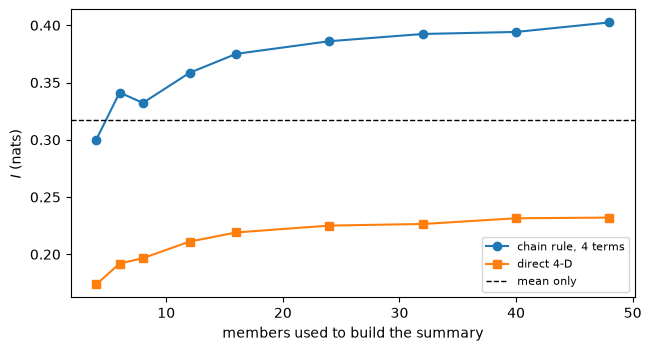

                           I raw   I excess        lam
mean-first                0.4025     0.3194     0.6043
kurt-first                0.2874     0.2045     0.5098
direct 4-D                0.2320     0.2099     0.5307
mean only                 0.3176     0.2941     0.5862

all 24 orderings, case-averaged:
  I raw      0.2863 to 0.4025   (spread 0.1163)
  I excess   0.2012 to 0.3194   (spread 0.1181)
  lam        0.5098 to 0.6043   (spread 0.0945)
  highest mean,std,skew,kurt;  lowest skew,kurt,std,mean

paired over 100 cases, kurt-first minus mean-first:
  I excess   -0.1149   sd 0.1600   se 0.0160
  lam        -0.0945   sd 0.1742   se 0.0174
  kurt-first higher in 22% of cases;  the two totals correlate +0.8521

term excess by feature and by where the ordering puts it:
feature        1st       2nd       3rd       4th
mean       +0.2941   +0.2293   +0.1702   +0.1225
std        +0.1031   +0.0662   +0.0347   +0.0107
skew       +0.0056   +0.0041   +0.0060   -0.0005
kurt       -0.0025   

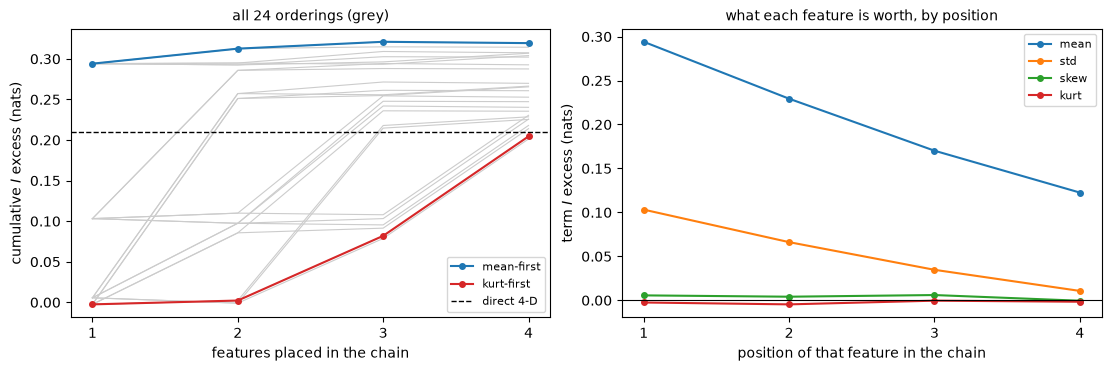

In [19]:
import itertools                # not imported in the cell above
import infomeasure as im        # nor this


def to_ranks(a):
    """Rank/copula transform, column-wise for 2-D input."""
    a = np.asarray(a, float)
    return R.copula(a) if a.ndim == 1 else np.column_stack(
        [R.copula(a[:, j]) for j in range(a.shape[1])])


def conditional_mi_nats(extra, target, given):
    """I(extra; target | given) in nats, same conventions as R.mi_nats."""
    return float(im.cmi(to_ranks(extra), to_ranks(target), cond=to_ranks(given),
                        approach="ksg", k=K, noise_level=0))


def lam_from_mi(mi_nats):
    """sqrt(1 - exp(-2I)) for I in nats, clamped at 0. Named apart from `lam` above,
    which one of the comparison cells rebinds to an array."""
    return np.sqrt(np.maximum(0.0, 1.0 - np.exp(-2.0 * np.asarray(mi_nats, float))))


def moment_summary(members):
    """(n_members, T) -> (T, 4) of mean, sd, skew, kurt."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = np.nanmean(members, axis=0)
        d = members - mean
        var = np.nanmean(d ** 2, axis=0)
        out = np.column_stack([mean, np.sqrt(var),
                               np.nanmean(d ** 3, axis=0) / var ** 1.5,
                               np.nanmean(d ** 4, axis=0) / var ** 2])
    return np.nan_to_num(out, nan=0.0)


MOMENT_NAMES = ["mean", "std", "skew", "kurt"]
ORDERS = {"mean-first": (0, 1, 2, 3), "kurt-first": (3, 2, 1, 0)}
ALL_ORDERS = list(itertools.permutations(range(4)))


def step_name(extra, given):
    """'skew | mean,std': the term that adds `extra` to the features already in."""
    return MOMENT_NAMES[extra] + ("" if not given else " | " + ",".join(
        MOMENT_NAMES[j] for j in given))


def chain_steps(summary, order=(0, 1, 2, 3)):
    """The four (name, extra, given) steps taken in `order`; `given` is None first."""
    return [(step_name(order[p], order[:p]), summary[:, order[p]],
             summary[:, list(order[:p])] if p else None) for p in range(4)]


def step_value(extra, target, given):
    return (R.mi_nats(extra, target, "ksg", param=K) if given is None
            else conditional_mi_nats(extra, target, given))


def step_table(summary, target, rng):
    """{(extra, frozenset(given)): (value, null)} for every step any ordering can ask.

    A KSG estimate is unchanged when the conditioning *columns* are permuted -- max
    norm over rank-transformed columns, asserted below -- so a step is fixed by which
    feature is added and which set is already in. That is 4 x 2^3 = 32 steps, and
    between them they cover all 24 orderings.
    """
    table = {}
    for extra in range(4):
        others = [j for j in range(4) if j != extra]
        for size in range(4):
            for given in itertools.combinations(others, size):
                columns = summary[:, list(given)] if given else None
                table[(extra, frozenset(given))] = (
                    step_value(summary[:, extra], target, columns),
                    np.mean([step_value(rng.permutation(summary[:, extra]), target,
                                        columns) for _ in range(N_PERMUTATIONS)]))
    return table


def order_terms(order):
    """(n_cases, 4) values and (n_cases, 4) nulls, in that ordering's own sequence."""
    stacked = np.array([[table[(order[p], frozenset(order[:p]))] for p in range(4)]
                        for table in step_tables])
    return stacked[..., 0], stacked[..., 1]


HELD_OUT_MEMBERS = [0, 12, 25, 37, 48]
SAMPLE_POINTS = [(la, lo) for la in range(6, 60, 13) for lo in range(0, 128, 32)]
N_PERMUTATIONS = 20
MEMBER_COUNTS = [4, 6, 8, 12, 16, 24, 32, 40, 48]
MEMBER_ORDER = np.random.default_rng(0).permutation(N)   # nested, model-mixed subsets

step_tables, direct_4d, direct_4d_null = [], [], []
chain_total_by_count, direct_4d_by_count = {}, {}

for lat_idx, lon_idx in SAMPLE_POINTS:
    # NaNs kept: moment_summary is nan-aware, and summarising members that have already
    # been zero-filled is a different quantity from `loo_mean` (members 10-19 are NaN for
    # all of calendar 1971). Only the target is zero-filled, as the estimators need.
    raw_members = F[:, :, lat_idx, lon_idx]
    for held in HELD_OUT_MEMBERS:
        target = np.nan_to_num(raw_members[held], nan=0.0)
        rng = np.random.default_rng(lat_idx * 1000 + lon_idx + held)
        summary = moment_summary(np.delete(raw_members, held, axis=0))

        # one table per case: every ordering is then a lookup, not a re-estimate
        step_tables.append(step_table(summary, target, rng))
        direct_4d.append(R.mi_nats(summary, target, "ksg", param=K))
        direct_4d_null.append(np.mean(
            [R.mi_nats(summary, rng.permutation(target), "ksg", param=K)
             for _ in range(N_PERMUTATIONS)]))

        subset = [m for m in MEMBER_ORDER if m != held]
        for count in MEMBER_COUNTS:
            counted = moment_summary(raw_members[subset[:count]])
            chain_total_by_count.setdefault(count, []).append(
                sum(step_value(e, target, g) for _, e, g in chain_steps(counted)))
            direct_4d_by_count.setdefault(count, []).append(
                R.mi_nats(counted, target, "ksg", param=K))

direct_4d, direct_4d_null = np.array(direct_4d), np.array(direct_4d_null)

# the invariance step_table leans on, on the last case the loop left behind
assert abs(conditional_mi_nats(summary[:, 0], target, summary[:, [1, 2, 3]])
           - conditional_mi_nats(summary[:, 0], target, summary[:, [3, 2, 1]])) < 1e-12

raw_total, excess_total = {}, {}
for order in ALL_ORDERS:
    value, null = order_terms(order)
    raw_total[order] = value.sum(axis=1)
    excess_total[order] = (value - null).sum(axis=1)

_value, _null = order_terms(ORDERS["mean-first"])
mean_only_value, mean_only_null = _value[:, 0], _null[:, 0]

# The exact chain rule is order-free -- any of the 24 orderings sums to the same
# I(f_n; mu, sigma, sk, ku) -- so every gap between the orderings below is estimator
# behaviour, not a different quantity.
for _label, _order in ORDERS.items():
    _value, _null = order_terms(_order)
    print("%-22s %9s %9s %9s" % (_label, "value", "null", "excess"))
    for _p in range(4):
        print("%-22s %+9.4f %+9.4f %+9.4f"
              % (step_name(_order[_p], _order[:_p]), _value[:, _p].mean(),
                 _null[:, _p].mean(), (_value[:, _p] - _null[:, _p]).mean()))
    print("%-22s %+9.4f %9s %+9.4f\n"
          % ("chain-rule total", raw_total[_order].mean(), "",
             excess_total[_order].mean()))

print("%7s %13s %13s" % ("members", "chain total", "direct 4-D"))
for count in MEMBER_COUNTS:
    print("%7d %13.4f %13.4f"
          % (count, np.mean(chain_total_by_count[count]),
             np.mean(direct_4d_by_count[count])))

fig, ax = plt.subplots(figsize=(6.4, 3.4), layout="constrained")
ax.plot(MEMBER_COUNTS, [np.mean(chain_total_by_count[c]) for c in MEMBER_COUNTS],
        "o-", label="chain rule, 4 terms")
ax.plot(MEMBER_COUNTS, [np.mean(direct_4d_by_count[c]) for c in MEMBER_COUNTS],
        "s-", label="direct 4-D")
ax.axhline(mean_only_value.mean(), ls="--", color="k", lw=1, label="mean only")
ax.set_xlabel("members used to build the summary")
ax.set_ylabel("$I$ (nats)")
ax.legend(fontsize=8)
plt.show()

print("%-22s %9s %10s %10s" % ("", "I raw", "I excess", "lam"))
for _label, _order in ORDERS.items():
    print("%-22s %9.4f %10.4f %10.4f"
          % (_label, raw_total[_order].mean(), excess_total[_order].mean(),
             lam_from_mi(excess_total[_order]).mean()))
print("%-22s %9.4f %10.4f %10.4f"
      % ("direct 4-D", direct_4d.mean(), (direct_4d - direct_4d_null).mean(),
         lam_from_mi(direct_4d - direct_4d_null).mean()))
print("%-22s %9.4f %10.4f %10.4f"
      % ("mean only", mean_only_value.mean(), (mean_only_value - mean_only_null).mean(),
         lam_from_mi(mean_only_value - mean_only_null).mean()))

_order_raw = np.array([raw_total[o].mean() for o in ALL_ORDERS])
_order_excess = np.array([excess_total[o].mean() for o in ALL_ORDERS])
_order_lam = np.array([lam_from_mi(excess_total[o]).mean() for o in ALL_ORDERS])
_best = ALL_ORDERS[int(_order_excess.argmax())]
_worst = ALL_ORDERS[int(_order_excess.argmin())]
print("\nall %d orderings, case-averaged:" % len(ALL_ORDERS))
for _name, _a in (("I raw", _order_raw), ("I excess", _order_excess), ("lam", _order_lam)):
    print("  %-10s %.4f to %.4f   (spread %.4f)"
          % (_name, _a.min(), _a.max(), np.ptp(_a)))
print("  highest %s;  lowest %s"
      % (",".join(MOMENT_NAMES[j] for j in _best),
         ",".join(MOMENT_NAMES[j] for j in _worst)))

_d = excess_total[ORDERS["kurt-first"]] - excess_total[ORDERS["mean-first"]]
_dlam = (lam_from_mi(excess_total[ORDERS["kurt-first"]])
         - lam_from_mi(excess_total[ORDERS["mean-first"]]))
print("\npaired over %d cases, kurt-first minus mean-first:" % len(step_tables))
for _name, _a in (("I excess", _d), ("lam", _dlam)):
    print("  %-10s %+.4f   sd %.4f   se %.4f"
          % (_name, _a.mean(), _a.std(ddof=1), _a.std(ddof=1) / np.sqrt(len(_a))))
print("  kurt-first higher in %.0f%% of cases;  the two totals correlate %+.4f"
      % (100 * np.mean(_d > 0),
         np.corrcoef(excess_total[ORDERS["mean-first"]],
                     excess_total[ORDERS["kurt-first"]])[0, 1]))


def position_excess(feature, position):
    """Term excess for `feature` placed at `position`, over every conditioning set that
    position can hold: one set at each end of the chain, three in the middle."""
    keys = {(feature, frozenset(o[:position]))
            for o in ALL_ORDERS if o[position] == feature}
    return np.mean([t[k][0] - t[k][1] for t in step_tables for k in keys])


by_position = np.array([[position_excess(j, p) for p in range(4)] for j in range(4)])
print("\nterm excess by feature and by where the ordering puts it:")
print("%-8s %9s %9s %9s %9s" % ("feature", "1st", "2nd", "3rd", "4th"))
for j in range(4):
    print("%-8s %+9.4f %+9.4f %+9.4f %+9.4f" % (MOMENT_NAMES[j], *by_position[j]))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")
positions = np.arange(1, 5)
for order in ALL_ORDERS:
    value, null = order_terms(order)
    axs[0].plot(positions, np.cumsum((value - null).mean(axis=0)), "-",
                color="0.8", lw=0.8, zorder=1)
for label, colour in (("mean-first", "tab:blue"), ("kurt-first", "tab:red")):
    value, null = order_terms(ORDERS[label])
    axs[0].plot(positions, np.cumsum((value - null).mean(axis=0)), "o-", ms=4,
                color=colour, label=label, zorder=3)
axs[0].axhline((direct_4d - direct_4d_null).mean(), ls="--", color="k", lw=1,
               label="direct 4-D")
axs[0].set_xticks(positions)
axs[0].set_xlabel("features placed in the chain")
axs[0].set_ylabel("cumulative $I$ excess (nats)")
axs[0].set_title("all 24 orderings (grey)", fontsize=10)
axs[0].legend(fontsize=8)

for j in range(4):
    axs[1].plot(positions, by_position[j], "o-", ms=4, label=MOMENT_NAMES[j])
axs[1].axhline(0, color="k", lw=0.8)
axs[1].set_xticks(positions)
axs[1].set_xlabel("position of that feature in the chain")
axs[1].set_ylabel("term $I$ excess (nats)")
axs[1].set_title("what each feature is worth, by position", fontsize=10)
axs[1].legend(fontsize=8)
plt.show()

## $\lambda_m$ from the chain rule, mapped

The same chain-rule total, now over the whole grid and every member, turned into $\lambda$
per member and averaged as before. Compared against the existing $\lambda_m$, which uses
the leave-one-out mean alone. As-is treatment; a cold run is about 10 minutes over eight
processes, so it is cached.

Two things differ from the sampled version above.

**The summary is built nan-aware.** Members 10-19 are NaN for all of calendar 1971, so
summarising members that have already been zero-filled is not the same quantity as
`loo_mean` above, which takes the nan-aware mean and zero-fills afterwards. Built the
second way, the chain's first term is *exactly* `I_N["as-is"]` -- asserted below -- so the
comparison against the mean-only $\lambda_m$ differs only by the terms that were added,
not by NaN handling.

**All seven terms are stored, not just their total.** The quantile comparison later needs
$q_{10},q_{50},q_{90}$ conditioned on the four moments, and keeping the terms separately
means one pass serves both, and lets each term be corrected by the null for *its own*
conditioning size before they are summed.

term           null  across-case   se of mean
mean         0.0242       0.0053       0.0004
std          0.0203       0.0050       0.0004
skew         0.0190       0.0047       0.0004
kurt         0.0195       0.0043       0.0003
q10          0.0204       0.0036       0.0003
q50          0.0202       0.0034       0.0003
q90          0.0204       0.0031       0.0002
                           mean      min      max
lam_m chain rule         0.6334   0.1739   0.9787
lam_m mean only          0.6089   0.0825   0.9767
difference               0.0244  -0.0481   0.2452

spatial correlation +0.989;  chain rule higher at 86.0% of cells


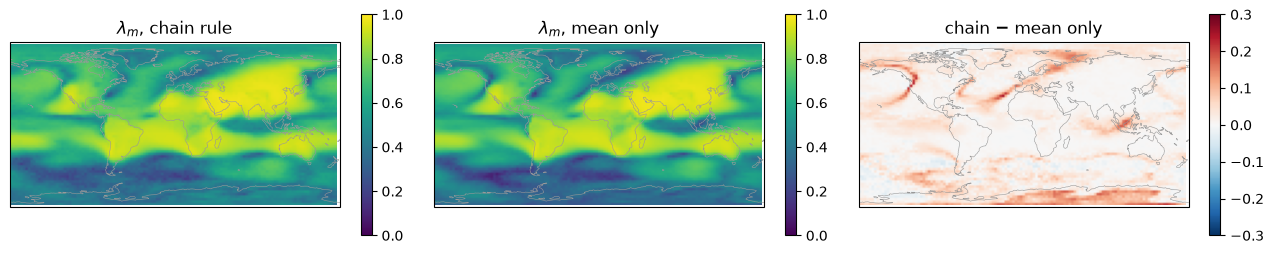

In [20]:
CHAIN_CACHE = "../data/granger_lin_chain_terms_cache_nats.npz"
QUANTILES = [10, 50, 90]
FEATURE_NAMES = ["mean", "std", "skew", "kurt", "q10", "q50", "q90"]
N_FEATURES = len(FEATURE_NAMES)


def feature_summary(members):
    """(n_members, T) -> (T, 7): the four moments, then q10, q50, q90.

    Nan-aware throughout, so `members` must arrive with its NaNs intact -- that is what
    makes column 0 the same quantity as `loo_mean`.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        quantiles = np.nanpercentile(members, QUANTILES, axis=0)
    return np.column_stack([moment_summary(members),
                            np.nan_to_num(quantiles.T, nan=0.0)])


def feature_chain_terms(members, held):
    """The seven chain terms for one held-out member, in nats."""
    summary = feature_summary(np.delete(members, held, axis=0))
    target = np.nan_to_num(members[held], nan=0.0)
    return [step_value(summary[:, j], target, None if j == 0 else summary[:, :j])
            for j in range(N_FEATURES)]


if os.path.exists(CHAIN_CACHE):
    chain_terms = np.load(CHAIN_CACHE)["chain_terms"]     # (N, 7, lat, lon), nats
else:
    chain_terms = np.empty((N, N_FEATURES) + F.shape[2:])
    for lat_idx in range(F.shape[2]):
        for lon_idx in range(F.shape[3]):
            raw_members = F[:, :, lat_idx, lon_idx]        # NaNs intact
            for held in range(N):
                chain_terms[held, :, lat_idx, lon_idx] = feature_chain_terms(
                    raw_members, held)
    np.savez_compressed(CHAIN_CACHE, chain_terms=chain_terms)

# nan-aware summary means the first term is the mean-only MI, exactly
assert np.allclose(chain_terms[:, 0], I_N["as-is"])

# Conditional nulls, one per position in the chain. These need the real summary, so they
# are measured here rather than with the unconditional null above: the null of term j
# depends on the size of the conditioning set, and using stand-in columns instead of the
# actual ones gets it wrong. Position 0 must reproduce the unconditional constant.
CHAIN_NULL_POINTS = [(la, lo) for la in range(3, 64, 9) for lo in range(0, 128, 17)]
CHAIN_NULL_MEMBERS = [0, 24, 48]

_chain_null_samples = np.array([
    [mi_null_nats(summary[:, j], np.nan_to_num(F[held, :, la, lo], nan=0.0),
                  None if j == 0 else summary[:, :j])
     for j in range(N_FEATURES)]
    for la, lo in CHAIN_NULL_POINTS
    for held in CHAIN_NULL_MEMBERS
    for summary in [feature_summary(np.delete(F[:, :, la, lo], held, axis=0))]])

CHAIN_NULLS = _chain_null_samples.mean(axis=0)
# Term 0 is the same quantity the unconditional null above measures, on many more cases,
# so take that estimate for it. Otherwise the chain and the mean-only lambda_m would be
# corrected by two different numbers for their shared first term, and their difference
# would carry that gap.
assert abs(CHAIN_NULLS[0] - NULL_NATS["as-is"]) < 0.0035
CHAIN_NULLS[0] = NULL_NATS["as-is"]

print("%-8s %10s %12s %12s" % ("term", "null", "across-case", "se of mean"))
for j, name in enumerate(FEATURE_NAMES):
    _sd = _chain_null_samples[:, j].std(ddof=1)
    print("%-8s %10.4f %12.4f %12.4f"
          % (name, CHAIN_NULLS[j], _sd,
             _sd / np.sqrt(len(_chain_null_samples))))



def chain_total(n_features, corrected=True):
    """Chain total over the first n_features terms, each less its own null."""
    terms = chain_terms[:, :n_features]
    if corrected:
        terms = terms - CHAIN_NULLS[:n_features][None, :, None, None]
    return terms.sum(axis=1)                               # (N, lat, lon)


chain_mi_per_member = chain_total(4)                       # null-corrected, 4 moments
lam_m_chain = lam_from_mi(chain_mi_per_member).mean(axis=0)   # (lat, lon)
lam_m_mean_only = LAM_M["as-is"]

print("%-22s %8s %8s %8s" % ("", "mean", "min", "max"))
for name, field in (("lam_m chain rule", lam_m_chain),
                    ("lam_m mean only", lam_m_mean_only),
                    ("difference", lam_m_chain - lam_m_mean_only)):
    print("%-22s %8.4f %8.4f %8.4f" % (name, field.mean(), field.min(), field.max()))
print("\nspatial correlation %+.3f;  chain rule higher at %.1f%% of cells"
      % (np.corrcoef(lam_m_chain.ravel(), lam_m_mean_only.ravel())[0, 1],
         100 * np.mean(lam_m_chain > lam_m_mean_only)))

fig, axs = plt.subplots(1, 3, figsize=(13, 2.9), subplot_kw={"projection": PROJ})
shared = Normalize(0, 1)
for ax, (field, title, cmap, nrm) in zip(axs, [
        (lam_m_chain, "$\\lambda_m$, chain rule", "viridis", shared),
        (lam_m_mean_only, "$\\lambda_m$, mean only", "viridis", shared),
        (lam_m_chain - lam_m_mean_only, "chain $-$ mean only", "RdBu_r",
         Normalize(-0.3, 0.3))]):
    h = panel(ax, field, cmap, nrm, title)
    fig.colorbar(h, ax=ax, shrink=0.85, label="")
plt.tight_layout()
plt.show()

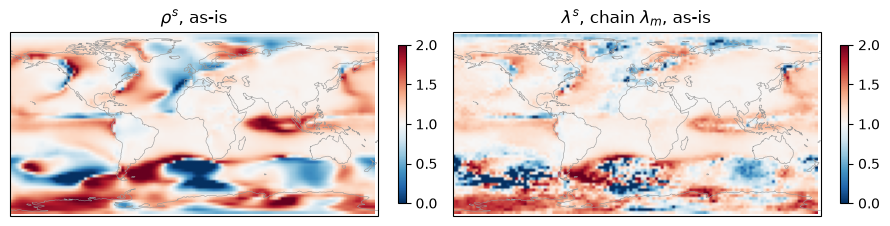

                                 mean     % > 1
rho^s                          1.0900     77.0%
lam^s, mean-only denom         1.1430     83.9%
lam^s, chain denom             1.0766     80.4%


In [21]:
treatment = "as-is"
rho_ratio = RHO_O_S[treatment] / RHO_M[treatment]              # unchanged
lam_ratio_chain = LAM_O_S[treatment] / lam_m_chain             # chain-rule denominator
lam_ratio_mean_only = LAM_O_S[treatment] / LAM_M[treatment]    # for the numbers below

fig, axs = plt.subplots(1, 2, figsize=(9, 2.6), subplot_kw={"projection": PROJ})
nrm_ratio = Normalize(0.0, 2.0)
h0 = panel(axs[0], rho_ratio, "RdBu_r", nrm_ratio, "$\\rho^s$, %s" % treatment)
h1 = panel(axs[1], lam_ratio_chain, "RdBu_r", nrm_ratio,
           "$\\lambda^s$, chain $\\lambda_m$, %s" % treatment)
fig.colorbar(h0, ax=axs[0], fraction=0.02)
fig.colorbar(h1, ax=axs[1], fraction=0.02)
plt.tight_layout()
plt.show()

print("%-28s %8s %9s" % ("", "mean", "% > 1"))
for name, field in (("rho^s", rho_ratio),
                    ("lam^s, mean-only denom", lam_ratio_mean_only),
                    ("lam^s, chain denom", lam_ratio_chain)):
    print("%-28s %8.4f %8.1f%%"
          % (name, np.nanmean(field),
             100 * R.area_weighted_fraction(field, lats, threshold=1.0)))

Text(0, 0.5, 'Density')

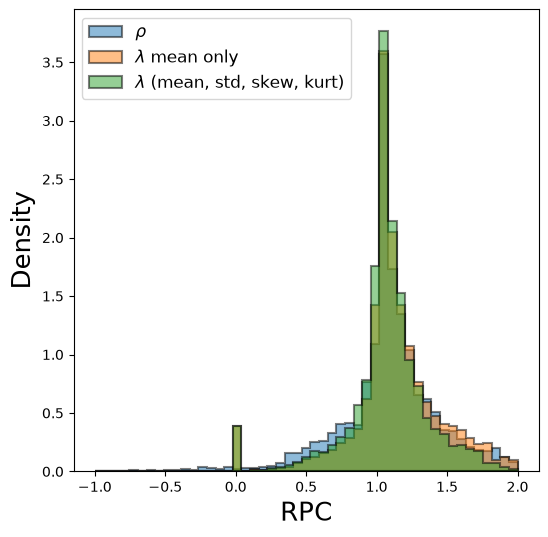

In [22]:
BINS = np.linspace(-1, 2, 50) 
BIN_LW = 1.5
LABEL_FONTSIZE = 19
fig, axs = plt.subplots(1, 1, figsize=(6, 6))

axs.hist(rho_ratio.flatten(), density=True, histtype='stepfilled', alpha=0.5, lw=BIN_LW, ec='k', label='$\\rho$', bins=BINS)
axs.hist(lam_ratio_mean_only.flatten(), density=True, histtype='stepfilled', alpha=0.5, lw=BIN_LW, ec='k', label='$\\lambda$ mean only', bins=BINS)
axs.hist(lam_ratio_chain.flatten(), density=True, histtype='stepfilled', alpha=0.5, lw=BIN_LW, ec='k', label='$\\lambda$ (mean, std, skew, kurt)', bins=BINS)

axs.legend(fontsize=12, loc='upper left')
axs.set_xlabel('RPC', fontsize=LABEL_FONTSIZE)
axs.set_ylabel('Density', fontsize=LABEL_FONTSIZE)

## Where does the curse of dimensionality start? Members added one at a time

Instead of summarising $F_{-n}$, add its members to the chain one at a time and watch what
each new term is worth. With $g_1,\dots,g_k$ the added members in a fixed random order and
$f_n$ the held-out target:

$$I(f_n;\,g_1,\dots,g_k) = I(f_n;g_1)
+ \sum_{j=2}^{k} I\big(g_j;f_n\mid g_1,\dots,g_{j-1}\big)$$

Every term is a 1-D `extra` against a 1-D target, so no term ever hands the estimator a
high-dimensional variable. The *conditioning set* still grows to $k-1$ columns though, and
`im.cmi` bias grows with it, so each term carries its own permutation null: the added member
is shuffled in time with the target and the conditioning set left aligned. The question is
at which $k$ the terms stop clearing those nulls.

Two references at each $k$: the direct $k$-dimensional estimate $I(f_n;g_1..g_k)$, which
pays the dimension penalty in full, and the linear baseline $I(f_n;\bar g_{1..k})$ that the
rest of this notebook uses.

The grid cell is the equatorial eastern Pacific -- lat index 31 ($1.40^\circ$S), lon index
85 ($239.1^\circ$E, i.e. $120.9^\circ$W), inside Niño 3.

Adds `PACIFIC_CELL`, `member_term` / `member_null` and the cumulative arrays, all
`(len(CHAIN_TARGETS), MAX_ADDED)`.

   k      term      null    excess   chain raw  chain excl     direct       mean
   1   +0.2601   +0.0286   +0.2315     +0.2601     +0.2315    +0.2424    +0.2308
   2   +0.0502   +0.0263   +0.0239     +0.3103     +0.2554    +0.2402    +0.2136
   3   +0.0987   +0.0200   +0.0787     +0.4089     +0.3341    +0.3002    +0.2808
   4   +0.0621   +0.0223   +0.0397     +0.4710     +0.3739    +0.3215    +0.3202
   5   +0.0510   +0.0246   +0.0264     +0.5220     +0.4003    +0.3336    +0.3066
   6   +0.0736   +0.0209   +0.0527     +0.5956     +0.4530    +0.3716    +0.3588
   7   +0.0427   +0.0232   +0.0196     +0.6384     +0.4726    +0.3592    +0.3561
   8   +0.0335   +0.0234   +0.0101     +0.6718     +0.4827    +0.3381    +0.3757
   9   +0.0245   +0.0263   -0.0018     +0.6964     +0.4809    +0.3128    +0.3661
  10   +0.0359   +0.0320   +0.0039     +0.7323     +0.4848    +0.3097    +0.3742
  11   +0.0388   +0.0297   +0.0091     +0.7711     +0.4939    +0.3067    +0.3868
  12   +0.0341   +0.0282   +

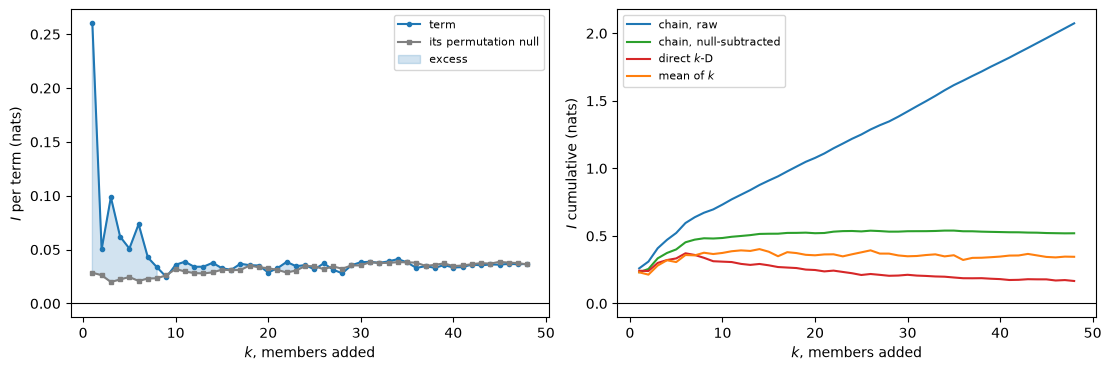

In [23]:
PACIFIC_CELL = (31, 85)          # 1.40S, 239.06E (120.9W) -- Nino 3
CHAIN_TARGETS = [0, 12, 25, 37, 48]
MAX_ADDED = 48                   # every other member, for N = 49

pacific_members = np.nan_to_num(F[:, :, PACIFIC_CELL[0], PACIFIC_CELL[1]], nan=0.0)

member_term = np.full((len(CHAIN_TARGETS), MAX_ADDED), np.nan)
member_null = np.full((len(CHAIN_TARGETS), MAX_ADDED), np.nan)
direct_value = np.full((len(CHAIN_TARGETS), MAX_ADDED), np.nan)
direct_null = np.full((len(CHAIN_TARGETS), MAX_ADDED), np.nan)
mean_value = np.full((len(CHAIN_TARGETS), MAX_ADDED), np.nan)
mean_null = np.full((len(CHAIN_TARGETS), MAX_ADDED), np.nan)

_order_rng = np.random.default_rng(0)
for ti, target_idx in enumerate(CHAIN_TARGETS):
    target = pacific_members[target_idx]
    order = [m for m in _order_rng.permutation(N) if m != target_idx][:MAX_ADDED]
    rng = np.random.default_rng(100 + target_idx)

    for k in range(1, MAX_ADDED + 1):
        added = pacific_members[order[k - 1]]
        given = pacific_members[order[:k - 1]].T if k > 1 else None

        member_term[ti, k - 1] = step_value(added, target, given)
        member_null[ti, k - 1] = np.mean([step_value(rng.permutation(added), target, given)
                                          for _ in range(N_PERMUTATIONS)])

        block = pacific_members[order[:k]].T                       # (T, k)
        direct_value[ti, k - 1] = R.mi_nats(block, target, "ksg", param=K)
        direct_null[ti, k - 1] = np.mean(
            [R.mi_nats(block, rng.permutation(target), "ksg", param=K)
             for _ in range(N_PERMUTATIONS)])

        block_mean = block.mean(axis=1)
        mean_value[ti, k - 1] = R.mi_nats(block_mean, target, "ksg", param=K)
        mean_null[ti, k - 1] = np.mean(
            [R.mi_nats(block_mean, rng.permutation(target), "ksg", param=K)
             for _ in range(N_PERMUTATIONS)])

term = member_term.mean(axis=0)
null = member_null.mean(axis=0)
excess = term - null
chain_raw = np.cumsum(member_term, axis=1).mean(axis=0)
chain_excess = np.cumsum(member_term - member_null, axis=1).mean(axis=0)
direct_excess = (direct_value - direct_null).mean(axis=0)
mean_excess = (mean_value - mean_null).mean(axis=0)
added_counts = np.arange(1, MAX_ADDED + 1)

print("%4s %9s %9s %9s %11s %11s %10s %10s"
      % ("k", "term", "null", "excess", "chain raw", "chain excl", "direct", "mean"))
for k in range(MAX_ADDED):
    print("%4d %+9.4f %+9.4f %+9.4f %+11.4f %+11.4f %+10.4f %+10.4f"
          % (k + 1, term[k], null[k], excess[k], chain_raw[k], chain_excess[k],
             direct_excess[k], mean_excess[k]))

_failed = [k + 1 for k in range(MAX_ADDED) if excess[k] <= 0]
print("\nfirst k whose term fails to clear its own null: %s" % (_failed[0] if _failed else None))
print("k maximising the cumulative excess:              %d" % (np.argmax(chain_excess) + 1))
print("k maximising the direct k-D excess:              %d" % (np.argmax(direct_excess) + 1))
print("per-term null, k=2 vs k=%d:                      %+.4f -> %+.4f nats"
      % (MAX_ADDED, null[1], null[-1]))
print("\n%-26s %9s %9s" % ("", "I (nats)", "lam"))
for label, total in (("chain raw, k=8", chain_raw[7]),
                     ("chain raw, k=%d" % MAX_ADDED, chain_raw[-1]),
                     ("chain excess, k=8", chain_excess[7]),
                     ("chain excess, k=%d" % MAX_ADDED, chain_excess[-1])):
    print("%-26s %9.4f %9.4f" % (label, total, lam_from_mi(total)))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained")

axs[0].plot(added_counts, term, "o-", ms=3, color="tab:blue", label="term")
axs[0].plot(added_counts, null, "s-", ms=3, color="0.5", label="its permutation null")
axs[0].fill_between(added_counts, null, term, where=term > null, color="tab:blue",
                    alpha=0.2, label="excess")
axs[0].axhline(0, color="k", lw=0.8)
axs[0].set_xlabel("$k$, members added")
axs[0].set_ylabel("$I$ per term (nats)")
axs[0].legend(fontsize=8)

axs[1].plot(added_counts, chain_raw, "-", color="tab:blue", label="chain, raw")
axs[1].plot(added_counts, chain_excess, "-", color="tab:green", label="chain, null-subtracted")
axs[1].plot(added_counts, direct_excess, "-", color="tab:red", label="direct $k$-D")
axs[1].plot(added_counts, mean_excess, "-", color="tab:orange", label="mean of $k$")
axs[1].axhline(0, color="k", lw=0.8)
axs[1].set_xlabel("$k$, members added")
axs[1].set_ylabel("$I$ cumulative (nats)")
axs[1].legend(fontsize=8)
plt.show()

## $\lambda_m$ with the quantiles added to the chain: four features against seven

Both totals come out of the one seven-term cache built above, so the only difference
between them is the three extra terms — same summary, same members, same NaN handling — and
each term is corrected by the null for *its own* conditioning size before the sum:

$$I_{\text{excess}}(f_n;\,\mu,\ldots,q_{90}) = \sum_{j=1}^{7}
\Big(I_j - I_{\text{null}}(j-1 \text{ conditions})\Big)$$

Raw, the three extra terms each contribute about 0.02 nats whether or not they carry
information, because that is what a conditional term's null is at $T=120$. The corrected
totals are what decide whether the deciles add anything.

Two checks close the cell: the constant nulls against nulls measured locally at
`SAMPLE_POINTS` with the same nan-aware summary, and the raw totals beside the corrected
ones.

                               mean       sd      min      max
I, 4 features                0.4044   0.3329   0.0123   1.5971
I, 7 features                0.4155   0.3441   0.0015   1.6315
lam_m, 4 features            0.6334   0.1998   0.1739   0.9787
lam_m, 7 features            0.6346   0.2045   0.1425   0.9800
lam_m difference             0.0012   0.0094  -0.0523   0.0421

spatial correlation +0.9992;  7 features higher at 67.3% of cells


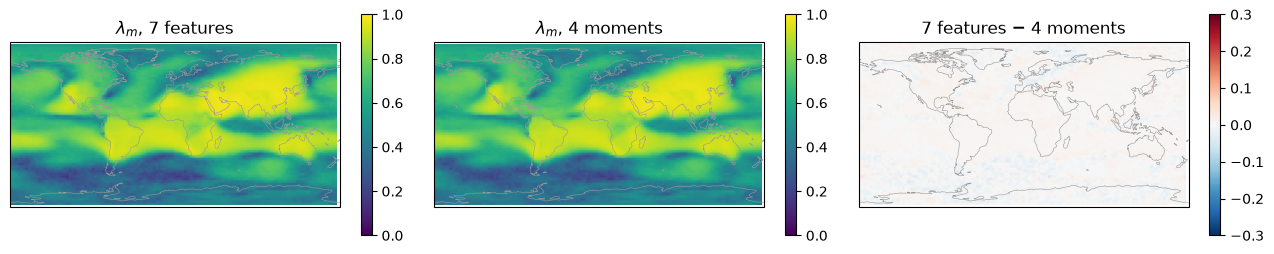

term                       constant        local  difference
mean                         0.0242       0.0231     -0.0011
std                          0.0203       0.0204      0.0001
skew                         0.0190       0.0193      0.0004
kurt                         0.0195       0.0197      0.0002
q10                          0.0204       0.0212      0.0008
q50                          0.0202       0.0214      0.0013
q90                          0.0204       0.0214      0.0010

                     I raw  I excess     lam raw  lam excess
1 feature           0.4023    0.3781      0.6386      0.6089
4 features          0.4873    0.4044      0.7132      0.6334
7 features          0.5594    0.4155      0.7572      0.6346


In [24]:
chain_mi_4 = chain_total(4)
chain_mi_7 = chain_total(7)
assert np.allclose(chain_mi_4, chain_mi_per_member)

lam_m_chain4 = lam_from_mi(chain_mi_4).mean(axis=0)      # (lat, lon)
lam_m_chain7 = lam_from_mi(chain_mi_7).mean(axis=0)

print("%-26s %8s %8s %8s %8s" % ("", "mean", "sd", "min", "max"))
for name, field in (("I, 4 features", chain_mi_4.mean(axis=0)),
                    ("I, 7 features", chain_mi_7.mean(axis=0)),
                    ("lam_m, 4 features", lam_m_chain4),
                    ("lam_m, 7 features", lam_m_chain7),
                    ("lam_m difference", lam_m_chain7 - lam_m_chain4)):
    print("%-26s %8.4f %8.4f %8.4f %8.4f"
          % (name, field.mean(), field.std(), field.min(), field.max()))
print("\nspatial correlation %+.4f;  7 features higher at %.1f%% of cells"
      % (np.corrcoef(lam_m_chain7.ravel(), lam_m_chain4.ravel())[0, 1],
         100 * np.mean(lam_m_chain7 > lam_m_chain4)))

fig, axs = plt.subplots(1, 3, figsize=(13, 2.9), subplot_kw={"projection": PROJ})
shared = Normalize(0, 1)
for ax, (field, title, cmap, nrm) in zip(axs, [
        (lam_m_chain7, "$\\lambda_m$, 7 features", "viridis", shared),
        (lam_m_chain4, "$\\lambda_m$, 4 moments", "viridis", shared),
        (lam_m_chain7 - lam_m_chain4, "7 features $-$ 4 moments", "RdBu_r",
         Normalize(-0.3, 0.3))]):
    h = panel(ax, field, cmap, nrm, title)
    fig.colorbar(h, ax=ax, shrink=0.85, label="")
plt.tight_layout()
plt.show()

# the constants against nulls measured locally, same nan-aware summary
local_null = {j: [] for j in range(N_FEATURES)}
for lat_idx, lon_idx in SAMPLE_POINTS:
    raw_members = F[:, :, lat_idx, lon_idx]
    for held in HELD_OUT_MEMBERS:
        summary = feature_summary(np.delete(raw_members, held, axis=0))
        target = np.nan_to_num(raw_members[held], nan=0.0)
        for j in range(N_FEATURES):
            local_null[j].append(mi_null_nats(summary[:, j], target,
                                              None if j == 0 else summary[:, :j]))

print("%-24s %10s %12s %11s" % ("term", "constant", "local", "difference"))
for j, name in enumerate(FEATURE_NAMES):
    local = float(np.mean(local_null[j]))
    print("%-24s %10.4f %12.4f %11.4f"
          % (name, CHAIN_NULLS[j], local, local - CHAIN_NULLS[j]))

print("\n%-16s %9s %9s %11s %11s" % ("", "I raw", "I excess", "lam raw", "lam excess"))
for n_features in (1, 4, 7):
    raw, corrected = chain_total(n_features, corrected=False), chain_total(n_features)
    print("%-16s %9.4f %9.4f %11.4f %11.4f"
          % ("%d feature%s" % (n_features, "" if n_features == 1 else "s"),
             raw.mean(), corrected.mean(),
             lam_from_mi(raw).mean(axis=0).mean(),
             lam_from_mi(corrected).mean(axis=0).mean()))